In [1]:
import os
print(os.listdir('/content'))

['.config', 'spam.csv', 'sample_data']


In [3]:
import pandas as  pd
df=pd.read_csv(
    "spam.csv",
    sep="\t",
    header=None,
    names=["label","text"]
)
print(df.head())
print(df.shape)

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [4]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df["label"].value_counts())

Shape: (5572, 2)

Columns:
Index(['label', 'text'], dtype='object')

Missing Values:
label    0
text     0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.isnull().sum()

,0
label,0
text,0


In [7]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [8]:
df["label"].value_counts(normalize=True)*100

,proportion
label,
ham,86.593683
spam,13.406317


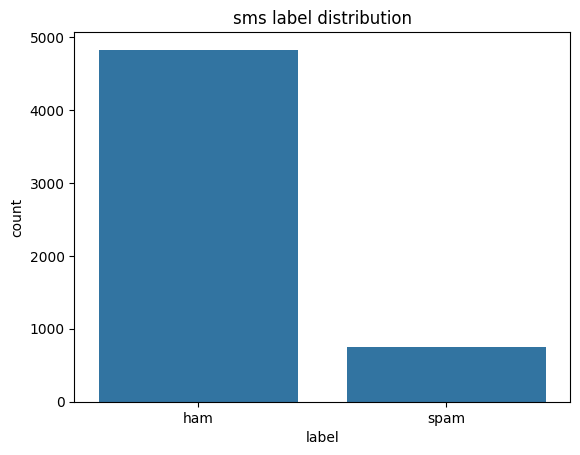

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(
    data=df,
    x="label"
)
plt.title("sms label distribution")
plt.show()

In [10]:
df["char_count"]=df["text"].apply(len)
df["word_count"]=df["text"].apply(
    lambda x: len(x.split())
)
print(df[["char_count","word_count"]].describe())

        char_count   word_count
count  5572.000000  5572.000000
mean     80.489950    15.597452
std      59.942907    11.404053
min       2.000000     1.000000
25%      36.000000     7.000000
50%      62.000000    12.000000
75%     122.000000    23.000000
max     910.000000   171.000000


In [12]:
df["char_count"]=df["text"].apply(len)
df["word_count"]=df["text"].apply(
    lambda x: len(x.split())
)
print(df[["char_count","word_count"]].describe())

        char_count   word_count
count  5572.000000  5572.000000
mean     80.489950    15.597452
std      59.942907    11.404053
min       2.000000     1.000000
25%      36.000000     7.000000
50%      62.000000    12.000000
75%     122.000000    23.000000
max     910.000000   171.000000


In [13]:
df.groupby("label")[["char_count","word_count"]].mean()

,char_count,word_count
label,,
ham,71.482487,14.310259
spam,138.670683,23.911647


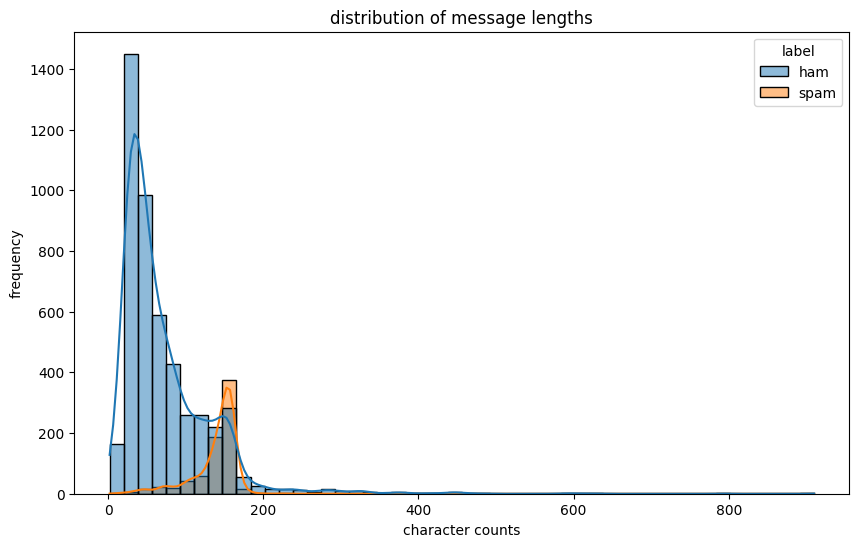

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="char_count",
    hue="label",
    bins=50,
    kde=True
)
plt.title("distribution of message lengths")
plt.xlabel("character counts")
plt.ylabel("frequency")
plt.show()

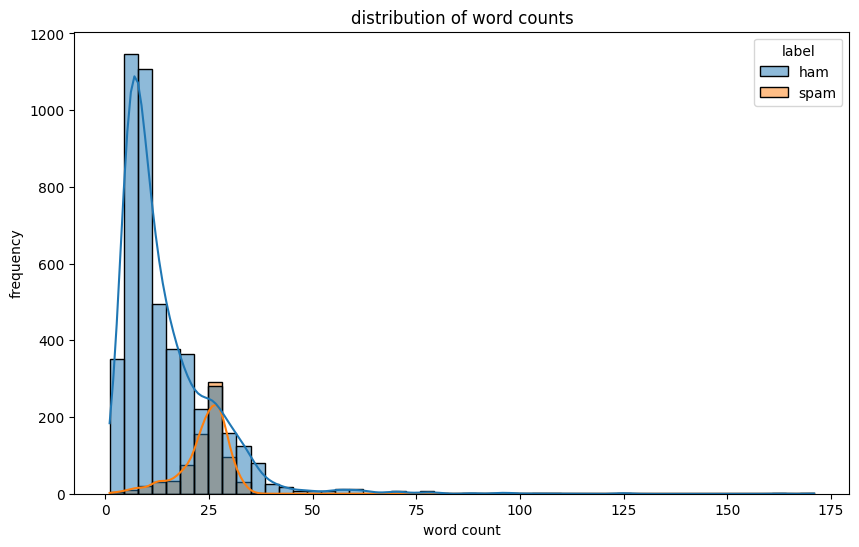

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=50,
    kde=True
)
plt.title("distribution of word counts")
plt.xlabel("word count")
plt.ylabel("frequency")
plt.show()

In [18]:
from collections import Counter
all_words=" ".join(df["text"]).lower().split()
word_freq=Counter(all_words)
print(word_freq.most_common(20))

[('to', 2237), ('i', 2217), ('you', 1921), ('a', 1433), ('the', 1329), ('u', 998), ('and', 968), ('is', 869), ('in', 859), ('my', 755), ('for', 704), ('your', 677), ('of', 614), ('me', 611), ('have', 571), ('call', 559), ('on', 521), ('are', 487), ('that', 470), ('it', 466)]


In [19]:
import pandas as pd
print("original data:")
print(df.head())
df["text_clean"]=df["text"].str.lower()
print("\nAfter lowercasing:")
print(df[["text","text_clean"]].head())

original data:
  label                                               text  char_count  \
0   ham  Go until jurong point, crazy.. Available only ...         111   
1   ham                      Ok lar... Joking wif u oni...          29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...         155   
3   ham  U dun say so early hor... U c already then say...          49   
4   ham  Nah I don't think he goes to usf, he lives aro...          61   

   word_count  
0          20  
1           6  
2          28  
3          11  
4          13  

After lowercasing:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                          text_clean  
0  go until jurong point, crazy.

In [20]:
df["text_clean"]

,text_clean
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will ü b going to esplanade fr home?
5569,"pity, * was in mood for that. so...any other s..."
5570,the guy did some bitching but i acted like i'd...


In [21]:
df["text"]

,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will ü b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [23]:
df["text_clean"]=df["text"].str.lower()

In [24]:
import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  return text
  df["text_clean"]=df["text"].apply(clean_text)
  df[["text","text_clean"]].head(10)

In [25]:
df[["text","text_clean"]].sample(5)

,text,text_clean
1562,Dnt worry...use ice pieces in a cloth pack.als...,dnt worry...use ice pieces in a cloth pack.als...
866,Congratulations ur awarded either a yrs supply...,congratulations ur awarded either a yrs supply...
3055,What happened to our yo date?,what happened to our yo date?
1718,WOW! The Boys R Back. TAKE THAT 2007 UK Tour. ...,wow! the boys r back. take that 2007 uk tour. ...
3523,Im sorry bout last nite it wasnt ur fault it ...,im sorry bout last nite it wasnt ur fault it ...


In [26]:
df[["text","text_clean"]].head(5)

,text,text_clean
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [27]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [28]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))
print(list(stop_words)[:20])

['me', 'such', 'then', 'out', 'just', 'weren', 'your', 'but', "they'll", 'before', 'above', 'myself', "i'd", 'once', 'you', "hadn't", "you've", 's', 'below', 'more']


In [29]:
sample_text="free entry into competition"
tokens=sample_text.split()
filtered_tokens=[
    word
    for word in tokens
    if word not in stop_words
]
print(filtered_tokens)

['free', 'entry', 'competition']


In [32]:
def preprocess_text(text):
  return text.lower()

In [37]:
import re
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))
def preprocess_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  tokens=text.split()
  tokens=[word for word in tokens if word not in stop_words]
  text=" ".join(tokens)
  return text

In [38]:
sample="FREE Entry into competition!!!"
print(preprocess_text(sample))

free entry competition


In [39]:
df["text_clean"]=df["text"].apply(preprocess_text)
df[["text","text_clean"]].head()

,text,text_clean
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [40]:
df["label_num"]=df['label'].map({
    "ham":0,
    "spam":1
})
df[["label","label_num"]].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [41]:
print(df["label_num"].value_counts())

label_num
0    4825
1     747
Name: count, dtype: int64


In [42]:
x=df["text_clean"]
y=df["label_num"]
print(x.head())
print()
print(y.head())

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: text_clean, dtype: object

0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64


In [43]:
df[["label","label_num"]].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
print("training size:",x_train.shape)
print("test size:",x_test.shape)

training size: (4457,)
test size: (1115,)


In [47]:
print(y_train.value_counts(normalize=True)*100)
print()
print(y_test.value_counts(normalize=True)*100)

label_num
0    86.582903
1    13.417097
Name: proportion, dtype: float64

label_num
0    86.636771
1    13.363229
Name: proportion, dtype: float64


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2

)

In [51]:
x_train_tfidf=vectorizer.fit_transform(x_train)

In [53]:
print(len(vectorizer.vocabulary_))

3000


In [52]:
x_test_tfidf=vectorizer.transform(x_test)


In [54]:
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB()
nb_model.fit(x_train_tfidf, y_train)

MultinomialNB()

In [55]:
y_pred=nb_model.predict(x_test_tfidf)


In [57]:
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("Accuracy:",accuracy_score(y_test,y_pred))


Accuracy: 0.9739910313901345


In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [59]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[966   0]
 [ 29 120]]


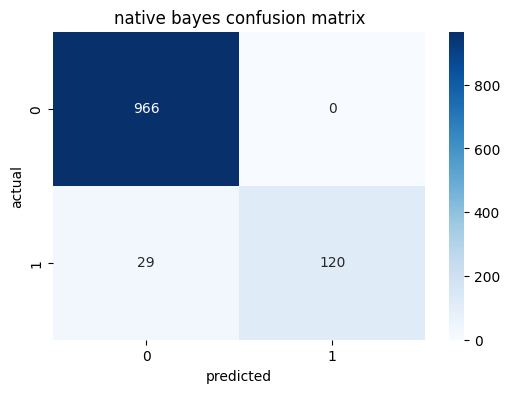

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"


)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("native bayes confusion matrix")
plt.show()

In [62]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [64]:
results=pd.DataFrame({
    "text":x_test,
    "actual":y_test,
    "predicted":y_pred
})

In [65]:
false_negatives=results[
    (results["actual"]==1) &
    (results["predicted"]==0)
]
for msg in false_negatives["text"].head(10):
  print("="*80)
  print(msg)

unsubscribed services get tons sexy babes hunks straight phone go httpgotbabescouk subscriptions
freemsg hey darling weeks word back id like fun still tb ok xxx std chgs send rcv
guess somebody know secretly fancies wanna find give us call landline dateboxessexcmxn pmin
talk sexy make new friends fall love worlds discreet text dating service text vip see could meet
hi ur lookin saucy daytime fun wiv busty married woman free next week chat sort time janinexx callsminmobsmorelkpoboxhpfl
ringtoneking
sorry missed call lets talk time im
latest news police station toilet stolen cops nothing go
themobhit link get premium pink panther game new sugababes crazy zebra animation badass hoody wallpaperall free
bloomberg message center wait apply future httpcareers bloombergcom


In [66]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(x_train_tfidf,y_train)
y_pred_lr=lr_model.predict(x_test_tfidf)

In [67]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [68]:
import joblib
joblib.dump(nb_model,"spam_model.pkl")
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")
print("model saved successfully")

model saved successfully


In [70]:
def predict_spam(message):

    # Step 1: preprocess the text
    cleaned_message = preprocess_text(message)

    # Step 2: convert text into TF-IDF features
    vectorized_message = vectorizer.transform([cleaned_message])

    # Step 3: predict class
    prediction = nb_model.predict(vectorized_message)[0]

    # Step 4: get probability
    probability = nb_model.predict_proba(vectorized_message)[0]

    # Step 5: return result
    if prediction == 1:
        return f"SPAM (Confidence: {probability[1]:.2%})"
    else:
        return f"HAM (Confidence: {probability[0]:.2%})"

In [71]:
print(predict_spam("congratulations! you won a free iphone."))

SPAM (Confidence: 63.80%)


In [74]:
messages=[
    "congratulations! you won a free iphone.",
    "claim your free cash prize now.",
    "are we meeting at 7 pm today?",
    "can you call me when you arrive?",
    "urgent! your account has been selected"
]
for msg in messages:
  print("="*60)
  print("message:",msg)
  print("prediction:",predict_spam(msg))

message: congratulations! you won a free iphone.
prediction: SPAM (Confidence: 63.80%)
message: claim your free cash prize now.
prediction: SPAM (Confidence: 97.61%)
message: are we meeting at 7 pm today?
prediction: HAM (Confidence: 97.91%)
message: can you call me when you arrive?
prediction: HAM (Confidence: 61.59%)
message: urgent! your account has been selected
prediction: SPAM (Confidence: 76.35%)
